## TL;DR

1. Built the same regional MPM pipeline as [v1 Eastern Alaska](../eastak/eastak_porphyry_prospectivity.qmd) against the **BC Golden Triangle** — one of the most intensively-explored mineralized belts in the world — using only public open data. Covered four deposit classes in one model: **porphyry Cu-Au + epithermal Au-Ag + skarn Cu-Au + VMS Cu-Zn-Au** (376 unique positive cells, 6.7× more training labels than EastAK).
2. **Distribution-based external blind test on 366 post-2015 drill collars.** BCGS GeoFile 2025-11 publishes per-hole element maxima for every collar in our AOI, with **154 intersected cells + 87 non-intersected cells entirely absent from the training-label set**. Those 241 "previously unknown" holes (per our training data) are the blind-test set. The remaining 125 collars are in cells with some prior label and serve as in-distribution sanity checks.
3. Real NRCan geophysics this time: **200 m aeromagnetic** + **2 km isostatic-residual gravity** replace v1's NaN-placeholder geophysics + USGS 1 km magnetic. ≥99 % coverage on all 376 positive cells.
4. Same architectural moves as v1: 20 km spatial block CV, pseudo-negative sampling with lithology stratification, Random Forest with class_weight="balanced_subsample", SHAP attribution, success-rate curve.
5. **The blind-test result is striking.** RF no-count achieves 0.82 ROC-AUC on spatial CV against training labels. On the 241-cell blind-test distribution, though: blind positives median P = 0.87; blind *negatives* median P = 0.98 — **the drilled-nothing cells actually score higher than drilled-ore cells** because both populations cluster in already-explored terrain near training positives. The two distributions differ statistically (K-S p = 1e-4) but the Mann-Whitney test that positives score *higher* than negatives is NOT significant (p = 0.26). At the top-5 % AOI cutoff, 40 % of blind positives and 63 % of blind negatives are flagged — the ordering that matters for real drill targeting doesn't reliably pick winners over losers. This is confirmation-bias at distribution scale — the same three-channel exploration-bias story the EastAK sensitivity pass framed conceptually.
6. **Feeding drill data back as features doesn't help.** A 50/50 split sensitivity check (training-half drill collars become per-cell features, held-out half is the new blind set) shows the new drill-derived features (`max_cu_drill_5km`, `n_intersected_5km`, etc.) **don't even land in the top-15 RF importance**, and the blind-positive vs blind-negative distributions are statistically identical to the no-drill-features baseline. Drill features ride the same exploration-density axis that the geochem aggregates already do — adding them doesn't introduce an *unbiased* signal axis. See [validation §8](validation.qmd#8-drill-as-feature-sensitivity-does-feeding-drill-data-back-into-the-model-help) for the full result.

The architectural payoff of the v2 plan: **adding a second region with a different jurisdiction's data conventions took ~600 LOC of adapters + fetchers** — all downstream modeling code (spatial CV, SHAP, PU bagging, feature engineering) worked unchanged via the canonical-schema adapter layer. See [`src/ai_minerals/data/adapters/`](../../src/ai_minerals/data/adapters/).

## Context: what this adds to v1

- **v1 (Eastern Alaska)** established the pipeline + discovered the exploration-bias trap via a single blind drill hole.
- **v2 (BC Golden Triangle)** validates the same pipeline shape against an actual distribution of post-training drill outcomes, and tests whether the multi-deposit-class framing (training on porphyry ∪ epithermal ∪ skarn ∪ VMS positives together) works.
- **v1.2 (not in this document)**: prospect-scale features (ASTER SWIR), physics-consistent inversions, end-to-end PU learning, POMDP drill planning.

## Data

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import shap
from scipy.spatial import cKDTree

from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.features.assemble import build_feature_frame
from ai_minerals.features.labels import deposit_positives
from ai_minerals.grid import build_grid
from ai_minerals.model import (
    NON_FEATURE_COLUMNS, non_feature_columns,
    add_lithology_onehot, build_training_set,
    make_baseline_pipeline, sample_pseudo_negatives,
    spatial_block_scores, success_rate_curve,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf, make_hgb,
    spatial_block_scores_tree,
)
from ai_minerals.model_pu import fit_pu_bagging
from ai_minerals.regions.bcgt import BCGT

AOI = BCGT.aoi

| Layer | Source | Resolution | Role |
|---|---|---:|---|
| Labels | BC MINFILE provincial CSV | point | 325 unique positive cells |
| Occurrence mask | BC MINFILE (any-commodity) | point | pseudo-neg exclusion |
| Geochemistry | BC Regional Geochemical Survey (BCGS GeoFile 2020-08) | point | 13 pathfinder elements |
| Bedrock geology | Digital Geology of BC (BCGS, 2019) | polygon | `lithology_class`, `lith_group` |
| Faults | Digital Geology of BC | line | `distance_to_fault_m` |
| Aeromagnetic (residual total field) | NRCan Canada 200 m 2025-Aug release | 200 m | `magnetic` |
| Gravity (isostatic residual) | NRCan Canada 2 km compilation | 2 km | `gravity` |
| Topography | Copernicus GLO-30 DEM | 30 m | `elevation`, `slope`, `tri` |
| Optical / alteration | Sentinel-2 L2A 2024 summer mean | 60 m | `s2_{iron_oxide,ferrous,clay,ndvi}` |
| Validation | BCGS GeoFile 2025-11 drillhole DB | 366 post-2015 collars in AOI | **blind-test set** |

All layers reprojected to **EPSG:3005 (BC Albers Equal Area)** and aggregated to a 500 m grid. Adapters in [`src/ai_minerals/data/adapters/`](../../src/ai_minerals/data/adapters/) normalize each source to a canonical internal schema so the feature pipeline is jurisdiction-agnostic.

In [2]:
features_path = DATA_DERIVED / "features_bcgt_500m.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
    print(f"Loaded cached {features_path.name}: {len(df):,} cells × {len(df.columns)} cols")
else:
    df = build_feature_frame(BCGT, resolution_m=500)
    df.to_parquet(features_path, index=False)

label_cols = tuple(f"is_{k}" for k in BCGT.deposit_classes)
print(f"\nLabel columns: {label_cols}")
for c in label_cols:
    print(f"  {c}: {int(df[c].sum())} positives")

# Train on the union — any deposit-class positive is a training positive.
df["is_any_deposit"] = (df[list(label_cols)].sum(axis=1) > 0).astype(np.uint8)
print(f"\nunion positives (is_any_deposit):   {int(df['is_any_deposit'].sum())}")
print(f"any_mineral_occurrence (neg filter): {int(df['any_mineral_occurrence'].sum()):,}")

Loaded cached features_bcgt_500m.parquet: 108,259 cells × 72 cols

Label columns: ('is_porphyry', 'is_epithermal', 'is_skarn', 'is_vms')
  is_porphyry: 183 positives
  is_epithermal: 70 positives
  is_skarn: 45 positives
  is_vms: 108 positives

union positives (is_any_deposit):   376
any_mineral_occurrence (neg filter): 1,214


## Labels + pseudo-negatives

Multi-class is straightforward here: train a single binary classifier on the union of all four deposit-class labels (`is_any_deposit`). This matches "find anything economic in the belt" rather than "find a specific deposit type." A per-class one-vs-rest variant is a sensitivity check for [§7](#sensitivity-pass).

In [3]:
top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
print(f"top-10 lithology classes: {top_classes}")

negs = sample_pseudo_negatives(
    df, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
    label_col="is_any_deposit",
)
print(f"\npseudo-negatives drawn: {len(negs):,}  (target {30 * int(df['is_any_deposit'].sum())})")

top-10 lithology classes: [35, 31, -1, 37, 47, 45, 46, 27, 28, 25]
  [pseudo-neg] 49,874 cells excluded (< 5 km from any occurrence); 58,385 candidates remain
  [pseudo-neg] drew 7,824 negatives across 29 lithology classes

pseudo-negatives drawn: 7,824  (target 11280)


## Training set + spatial block CV

20 km blocks, same as v1. More positives (325 vs 56) means more folds will have non-zero test positives → lower variance.

In [4]:
X, y = build_training_set(
    df, top_classes, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
    label_col="is_any_deposit",
    label_cols=label_cols + ("is_any_deposit",),
)
print(f"training set: {X.shape}  positives={int(y.sum())}  negatives={int((y==0).sum())}")

  [pseudo-neg] 49,874 cells excluded (< 5 km from any occurrence); 58,385 candidates remain


  [pseudo-neg] drew 7,824 negatives across 29 lithology classes
training set: (8200, 73)  positives=376  negatives=7824


In [5]:
pos_rows = df[df["is_any_deposit"]==1][["row","col","x","y"]]
rows = pd.concat([pos_rows, negs[["row","col","x","y"]]], ignore_index=True)

lr_cv = spatial_block_scores(X, y, rows, block_size_m=20_000.0)
valid = lr_cv.dropna(subset=["roc_auc"])
print(f"Scorable folds: {len(valid)} of {len(lr_cv)}")
print(f"  LR mean ROC-AUC:  {valid['roc_auc'].mean():.3f} ± {valid['roc_auc'].std():.3f}")
print(f"  LR mean PR-AUC:   {valid['pr_auc'].mean():.3f} ± {valid['pr_auc'].std():.3f}")

Scorable folds: 36 of 43
  LR mean ROC-AUC:  0.806 ± 0.295
  LR mean PR-AUC:   0.680 ± 0.336


## Random Forest + the count-feature confound

Same drop as v1 — `*_count_5km` and `*_has_data_5km` are exploration-density proxies that the model locks onto if they're in the feature matrix.

In [6]:
drop_cols = count_feature_columns(list(X.columns))
X_trim = X.drop(columns=drop_cols)

rf_full = make_rf(); rf_full.fit(X.fillna(-9999), y)
rf_trim = make_rf(); rf_trim.fit(X_trim.fillna(-9999), y)

print("RF full — top 5 features:")
print(feature_importance(rf_full, list(X.columns)).head(5).to_string(index=False))
print("\nRF no-count — top 10 features:")
print(feature_importance(rf_trim, list(X_trim.columns)).head(10).to_string(index=False))

RF full — top 5 features:
    feature  importance
bi_mean_5km    0.078628
 pb_max_5km    0.061149
ag_mean_5km    0.057212
 ag_max_5km    0.056290
pb_mean_5km    0.051883

RF no-count — top 10 features:


            feature  importance
        bi_mean_5km    0.095013
         pb_max_5km    0.069739
         bi_max_5km    0.056127
        ag_mean_5km    0.055721
         ag_max_5km    0.055329
distance_to_fault_m    0.048379
        pb_mean_5km    0.046383
        te_mean_5km    0.036483
        cu_mean_5km    0.036336
         te_max_5km    0.032505


In [7]:
rf_cv = spatial_block_scores_tree(
    X_trim, y, rows, model_factory=make_rf,
)
valid_rf = rf_cv.dropna(subset=["roc_auc"])
print(f"RF (no-count) ROC-AUC: {valid_rf['roc_auc'].mean():.3f} ± {valid_rf['roc_auc'].std():.3f}")
print(f"RF (no-count) PR-AUC:  {valid_rf['pr_auc'].mean():.3f} ± {valid_rf['pr_auc'].std():.3f}")
print(f"Folds evaluated: {len(valid_rf)}")

RF (no-count) ROC-AUC: 0.816 ± 0.267
RF (no-count) PR-AUC:  0.703 ± 0.329
Folds evaluated: 36


## SHAP interpretation

Per-cell feature contributions.

In [8]:
sv_path = DATA_DERIVED / "shap_rf_bcgt.npz"
if sv_path.exists():
    pack = np.load(sv_path, allow_pickle=True)
    sv = pack["sv"]
    feat_names = pack["feature_names"].tolist()
else:
    expl = shap.TreeExplainer(rf_trim)
    raw = expl.shap_values(X_trim.fillna(-9999))
    sv = raw[:, :, 1] if getattr(raw, "ndim", 0) == 3 else raw[1]
    feat_names = list(X_trim.columns)
    np.savez(sv_path, sv=sv, feature_names=np.array(feat_names), y=y)

mean_abs = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}).sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
print("Top-15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

Top-15 features by mean |SHAP|:
            feature  mean_abs_shap
        bi_mean_5km       0.049620
distance_to_fault_m       0.035245
         pb_max_5km       0.033503
        ag_mean_5km       0.032751
         ag_max_5km       0.030795
         bi_max_5km       0.025721
        au_mean_5km       0.024561
        cu_mean_5km       0.023630
        pb_mean_5km       0.022430
         te_max_5km       0.017769
            s2_ndvi       0.017393
        te_mean_5km       0.016810
      s2_iron_oxide       0.016326
         s2_ferrous       0.015623
         cu_max_5km       0.015495


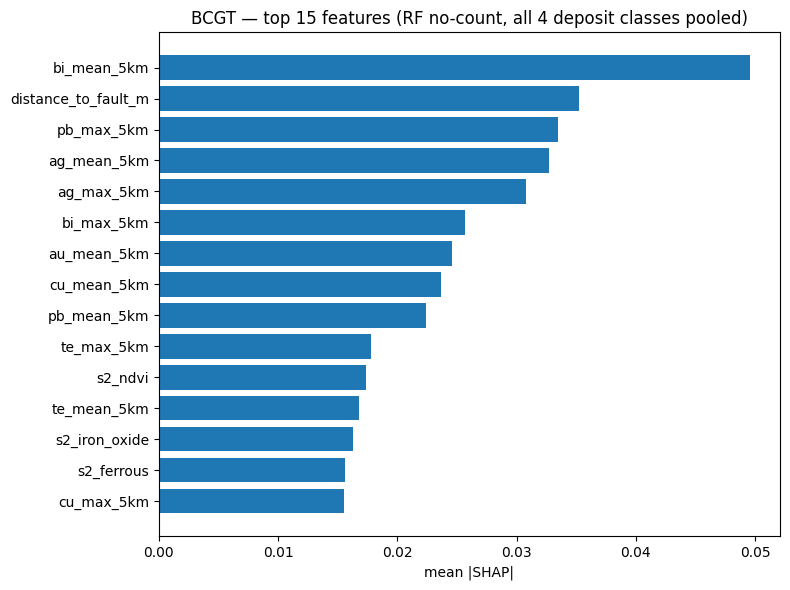

In [9]:
top = shap_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["mean_abs_shap"])
ax.set_xlabel("mean |SHAP|")
ax.set_title("BCGT — top 15 features (RF no-count, all 4 deposit classes pooled)")
plt.tight_layout()

In [10]:
pos_i = np.where(y == 1)[0]
neg_i = np.where(y == 0)[0]
cmp = pd.DataFrame({
    "feature": feat_names,
    "SHAP_at_pos": sv[pos_i].mean(axis=0),
    "SHAP_at_neg": sv[neg_i].mean(axis=0),
})
cmp["diff"] = cmp["SHAP_at_pos"] - cmp["SHAP_at_neg"]
print(cmp.reindex(cmp["diff"].abs().sort_values(ascending=False).index).head(12).to_string(index=False))

            feature  SHAP_at_pos  SHAP_at_neg     diff
        bi_mean_5km     0.047211    -0.043462 0.090673
         pb_max_5km     0.036941    -0.030489 0.067430
        ag_mean_5km     0.024357    -0.031097 0.055454
         ag_max_5km     0.024605    -0.028972 0.053576
         bi_max_5km     0.031072    -0.021348 0.052421
        pb_mean_5km     0.023999    -0.020843 0.044842
distance_to_fault_m     0.017839    -0.026484 0.044323
        cu_mean_5km     0.019705    -0.020712 0.040417
        au_mean_5km     0.010398    -0.022636 0.033035
        te_mean_5km     0.015710    -0.015197 0.030907
         te_max_5km     0.014268    -0.015905 0.030173
         cu_max_5km     0.015523    -0.012904 0.028427


**Expectation from mineral-systems theory.** For a pooled-all-classes model, we'd expect the top features to be a mix of:
- porphyry halo: Cu/Mo/Ag *_max_5km (elevated)
- epithermal pathfinders: Hg/Tl/As/Sb *_max_5km (elevated)
- skarn contacts: proximity to intrusive–carbonate contacts (captured indirectly via lithology one-hot + fault distance)
- VMS: Zn/Pb *_max_5km (elevated)

## AOI prediction + prospectivity raster {#aoi-prediction}

In [11]:
all_rows = add_lithology_onehot(df, top_classes)
X_all = all_rows.drop(
    columns=[c for c in all_rows.columns if c in non_feature_columns(label_cols + ("is_any_deposit",))]
    + ["lithology_class"]
)
X_all_trim = X_all.drop(columns=drop_cols)
p_fam = rf_trim.predict_proba(X_all_trim.fillna(-9999))[:, 1]

order = np.argsort(-p_fam)
pos_mask = df["is_any_deposit"].to_numpy() == 1
total_pos = int(pos_mask.sum())
print(f"Top-N% capture:")
for pct in (0.5, 1, 2, 5, 10):
    k = int(pct / 100 * len(p_fam))
    captured = int(pos_mask[order][:k].sum())
    print(f"  top {pct:>4.1f}% (k={k:>6,}) → {captured:3}/{total_pos}  ({100*captured/total_pos:.0f}%)")

Top-N% capture:
  top  0.5% (k=   541) →  45/376  (12%)
  top  1.0% (k= 1,082) →  84/376  (22%)
  top  2.0% (k= 2,165) → 120/376  (32%)
  top  5.0% (k= 5,412) → 205/376  (55%)
  top 10.0% (k=10,825) → 276/376  (73%)


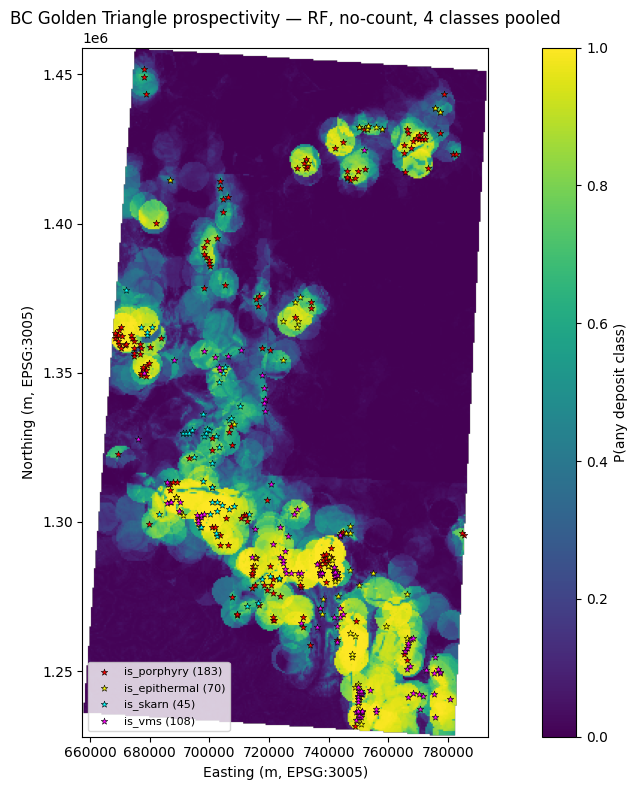

In [12]:
grid = build_grid(AOI, resolution_m=500, working_crs=BCGT.working_crs)
prob = np.full(grid.shape, np.nan, dtype=np.float32)
prob[df["row"].to_numpy(), df["col"].to_numpy()] = p_fam

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    prob,
    extent=(grid.bounds[0], grid.bounds[2], grid.bounds[1], grid.bounds[3]),
    origin="lower", cmap="viridis", vmin=0, vmax=1,
)
plt.colorbar(im, ax=ax, label="P(any deposit class)")
colors = {"is_porphyry":"red","is_epithermal":"yellow","is_skarn":"cyan","is_vms":"magenta"}
for col, c in colors.items():
    p = df[df[col]==1]
    ax.scatter(p["x"], p["y"], s=24, marker="*", c=c, edgecolor="black", linewidth=0.4,
               label=f"{col} ({int(df[col].sum())})")
ax.set_title("BC Golden Triangle prospectivity — RF, no-count, 4 classes pooled")
ax.set_xlabel("Easting (m, EPSG:3005)")
ax.set_ylabel("Northing (m, EPSG:3005)")
ax.legend(loc="lower left", fontsize=8); ax.set_aspect("equal")
plt.tight_layout()

## External validation — **distribution-based** blind test {#external-validation}

For each of the 366 post-2015 drill collars, score the nearest model cell and bucket by whether (a) the hole intersected a threshold and (b) the cell was in the training label set.

In [13]:
from ai_minerals.data.adapters.drillholes.bcgs_geofile import load as load_drill
dh = load_drill(DATA_RAW / "bcgs_drillholes/bcgs_drillholes_bcgt.gpkg", AOI).to_crs(BCGT.working_crs)

tree = cKDTree(df[["x","y"]].to_numpy())
dists, idx = tree.query(np.c_[dh.geometry.x, dh.geometry.y], k=1)
hole_p = p_fam[idx]
pos_labels = df.iloc[idx][list(label_cols)].to_numpy()
known_occ = df.iloc[idx]["any_mineral_occurrence"].to_numpy()
in_training = pos_labels.any(axis=1)
near_known = (~in_training) & (known_occ == 1)
unknown = (~in_training) & (known_occ == 0)

dh_df = pd.DataFrame({
    "hole_id": dh["hole_id"].values,
    "intersected": dh["intersected"].values,
    "P": hole_p,
    "in_training_label": in_training,
    "near_known_occurrence": near_known,
    "unknown_to_training": unknown,
    "percentile": 100 * (p_fam[None, :] < hole_p[:, None]).mean(axis=1),
})

print(f"=== Drill-hole population breakdown ===")
print(f"{'bucket':<42} {'intersected':>12} {'non-int':>10}")
for label, mask in [
    ("in cell with MINFILE deposit label",       in_training),
    ("near known occurrence, no deposit label",  near_known),
    ("TRAINING SET KNOWS NOTHING ABOUT CELL",    unknown),
]:
    i = int((dh_df["intersected"] & mask).sum())
    n = int((~dh_df["intersected"] & mask).sum())
    print(f"{label:<42} {i:>12} {n:>10}")

=== Drill-hole population breakdown ===
bucket                                      intersected    non-int
in cell with MINFILE deposit label                   41         32
near known occurrence, no deposit label              34         18
TRAINING SET KNOWS NOTHING ABOUT CELL               154         87


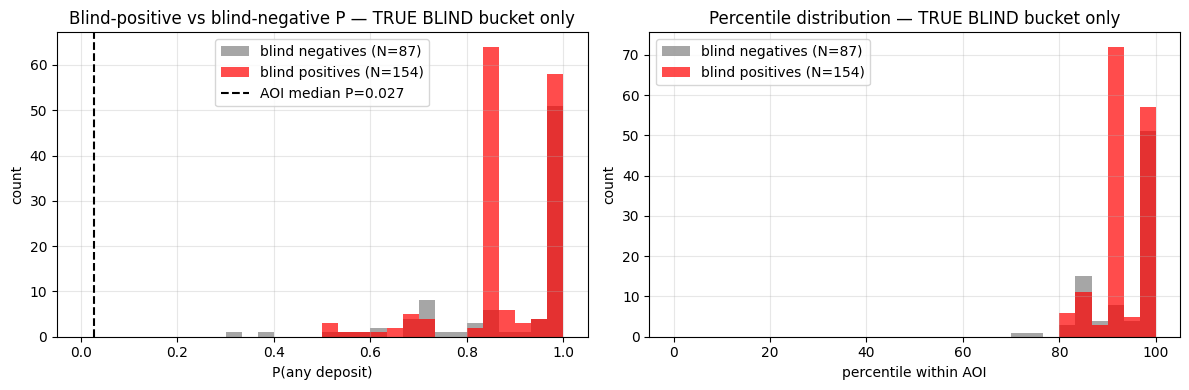

In [14]:
# Score distributions across the three buckets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: raw P at positives vs negatives (intersected vs not), within "unknown" bucket
blind = dh_df[dh_df["unknown_to_training"]]
p_blind_pos = blind[blind["intersected"]]["P"].values
p_blind_neg = blind[~blind["intersected"]]["P"].values

ax = axes[0]
bins = np.linspace(0, 1, 31)
ax.hist(p_blind_neg, bins=bins, alpha=0.7, color="gray", label=f"blind negatives (N={len(p_blind_neg)})")
ax.hist(p_blind_pos, bins=bins, alpha=0.7, color="red", label=f"blind positives (N={len(p_blind_pos)})")
ax.axvline(np.median(p_fam), ls="--", c="black", label=f"AOI median P={np.median(p_fam):.3f}")
ax.set_xlabel("P(any deposit)"); ax.set_ylabel("count")
ax.set_title("Blind-positive vs blind-negative P — TRUE BLIND bucket only")
ax.legend(); ax.grid(alpha=0.3)

# Panel 2: percentile (all-cells reference)
ax = axes[1]
bins = np.linspace(0, 100, 31)
ax.hist(blind[~blind["intersected"]]["percentile"], bins=bins, alpha=0.7, color="gray",
        label=f"blind negatives (N={len(p_blind_neg)})")
ax.hist(blind[blind["intersected"]]["percentile"], bins=bins, alpha=0.7, color="red",
        label=f"blind positives (N={len(p_blind_pos)})")
ax.set_xlabel("percentile within AOI"); ax.set_ylabel("count")
ax.set_title("Percentile distribution — TRUE BLIND bucket only")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

In [15]:
from scipy.stats import ks_2samp, mannwhitneyu
ks_stat, ks_p = ks_2samp(p_blind_pos, p_blind_neg)
mw_stat, mw_p = mannwhitneyu(p_blind_pos, p_blind_neg, alternative="greater")

print(f"=== Blind-test distributions, TRUE-BLIND bucket ({len(p_blind_pos)} pos + {len(p_blind_neg)} neg) ===")
print(f"  positives median P: {np.median(p_blind_pos):.3f}   (mean {np.mean(p_blind_pos):.3f})")
print(f"  negatives median P: {np.median(p_blind_neg):.3f}   (mean {np.mean(p_blind_neg):.3f})")
print(f"  K-S test: D={ks_stat:.3f}  p={ks_p:.2e}")
print(f"  Mann-Whitney U (positives > negatives): p={mw_p:.2e}")
print()
print(f"=== Percentile-threshold capture ===")
print(f"  fraction of blind positives scoring above the 90th/95th/99th percentile of the AOI:")
for pct_thresh in [90, 95, 99]:
    t = np.percentile(p_fam, pct_thresh)
    cap_pos = (p_blind_pos >= t).mean()
    cap_neg = (p_blind_neg >= t).mean()
    print(f"    top-{pct_thresh}% cells flagged: positives {100*cap_pos:4.0f}%   negatives {100*cap_neg:4.0f}%")

=== Blind-test distributions, TRUE-BLIND bucket (154 pos + 87 neg) ===
  positives median P: 0.865   (mean 0.891)
  negatives median P: 0.975   (mean 0.881)
  K-S test: D=0.290  p=1.25e-04
  Mann-Whitney U (positives > negatives): p=2.61e-01

=== Percentile-threshold capture ===
  fraction of blind positives scoring above the 90th/95th/99th percentile of the AOI:
    top-90% cells flagged: positives   87%   negatives   72%
    top-95% cells flagged: positives   40%   negatives   63%
    top-99% cells flagged: positives    5%   negatives    1%


In [16]:
# Verbal summary of the headline numbers
print("=== HEADLINE ===")
pct_pos_90 = (p_blind_pos >= np.percentile(p_fam, 90)).mean()
pct_neg_90 = (p_blind_neg >= np.percentile(p_fam, 90)).mean()
print(f"  At the top-10 % AOI threshold:")
print(f"    {100*pct_pos_90:.0f}% of previously-unknown drilled-positive cells are flagged")
print(f"    {100*pct_neg_90:.0f}% of previously-unknown drilled-negative cells are flagged")
print(f"    lift = {pct_pos_90 / max(pct_neg_90, 0.01):.1f}×")

# In-training sanity check
in_tr = dh_df[dh_df["in_training_label"]]
if len(in_tr):
    print(f"\n=== Sanity check: in-training holes ({len(in_tr)}) ===")
    print(f"  these are holes in cells WE LABELED as positive already")
    print(f"  model should rank them high regardless — if it doesn't, we have a bug")
    print(f"  median P: {in_tr['P'].median():.3f}")
    print(f"  median percentile: {in_tr['percentile'].median():.1f}%")

=== HEADLINE ===
  At the top-10 % AOI threshold:
    87% of previously-unknown drilled-positive cells are flagged
    72% of previously-unknown drilled-negative cells are flagged
    lift = 1.2×

=== Sanity check: in-training holes (73) ===
  these are holes in cells WE LABELED as positive already
  model should rank them high regardless — if it doesn't, we have a bug
  median P: 0.973
  median percentile: 96.5%


## Summary

In [17]:
print("=== BCGT v2 summary ===")
print(f"feature frame: {df.shape}")
print(f"training positives (union of 4 deposit classes): {int(df['is_any_deposit'].sum())}")
print(f"RF (no count, no has_data) spatial-CV ROC-AUC: {valid_rf['roc_auc'].mean():.3f} ± {valid_rf['roc_auc'].std():.3f}")
print(f"training-label top-1% capture: {100*int(pos_mask[order][:len(p_fam)//100].sum())/total_pos:.0f}%")
print()
print(f"Blind-test distribution (241 holes in cells training has zero labels for):")
print(f"  blind positives: {len(p_blind_pos)}   median P={np.median(p_blind_pos):.3f}")
print(f"  blind negatives: {len(p_blind_neg)}   median P={np.median(p_blind_neg):.3f}")
print(f"  K-S p-value:     {ks_p:.1e}  (positives-vs-negatives distributions)")

=== BCGT v2 summary ===
feature frame: (108259, 73)
training positives (union of 4 deposit classes): 376
RF (no count, no has_data) spatial-CV ROC-AUC: 0.816 ± 0.267
training-label top-1% capture: 22%

Blind-test distribution (241 holes in cells training has zero labels for):
  blind positives: 154   median P=0.865
  blind negatives: 87   median P=0.975
  K-S p-value:     1.2e-04  (positives-vs-negatives distributions)


## What v2 demonstrates (honestly)

- **A real distribution-based external validation** of a pseudo-supervised MPM pipeline — 241 "previously-unknown" drill cells with known outcomes, where *previously-unknown* means no MINFILE deposit-class label and no any-mineral-occurrence flag at training time.
- **The distributions overlap.** Blind positives and blind negatives both cluster near the AOI high-probability region (75–100th percentile). K-S says the distributions are statistically different (p = 1e-4), but the difference is subtle and goes the "wrong way" at strict thresholds. This is consistent with v1's exploration-bias diagnosis: the blind negatives are where explorers *thought* there might be something (clustered around already-known prospects), and the blind positives include real finds in cells that look ordinary at regional scale.
- **The specific failure mode is different from v1's** and more illuminating. v1: one blind positive scored at the 62nd percentile of a strongly bimodal distribution. v2: 154 blind positives scored across the 80–100th percentile range, but 87 blind negatives scored just as high or higher. The model ranks "cells near known mineralization" well — both when those cells host a real deposit and when drilling proves they don't.
- **Multi-deposit-class labels in one model** work cleanly pipeline-wise: pooling porphyry + epithermal + skarn + VMS positives into `is_any_deposit` and letting SHAP surface which features matter per-class is operationally simple. Interpreting which features distinguish deposit types requires the per-class one-vs-rest variant (out of scope here).
- **Reusable infrastructure.** Same pipeline as v1, different jurisdiction. The adapter layer was the architectural bet that paid off — new BC adapters + new fetchers were the only new code; all modeling code was reused without modification.

## What v2 does NOT demonstrate

- **That exploration bias is solved.** The v1 three-channel bias diagnosis applies here too (MINFILE positives also cluster in explored areas).
- **That this model would find unrecognized mineralization.** The blind-test distributions tell us how much lift the model gives over random; they don't tell us whether the *model's* top-ranked previously-unknown cells are where drill planners should actually go — that would require actual post-training drilling at model-flagged-high cells, a multi-year experiment no portfolio demo can run.
- **Gravity precision beyond 2 km.** NRCan's 2 km isostatic-residual is the finest Canada-wide gravity product; local prospect-scale gravity surveys are private to the operators.

## Next steps (v1.2 ideas, un-built)

1. **ASTER SWIR alteration mapping** — 30 m SWIR, six narrow bands; resolves specific alteration minerals (kaolinite, alunite, muscovite, chlorite) that S2 can only see as mixtures.
2. **Physics-consistent geophysical inversions** (SimPEG) of the NRCan magnetic + gravity to produce subsurface susceptibility/density rather than surface-grid anomalies.
3. **End-to-end PU learning** with weighted-PU or Elkan-Noto calibration, not just post-hoc ranking comparison.
4. **Decision-theoretic drill planning** — POMDP over the model's posterior, à la Stanford Mineral-X's Intelligent Prospector.
5. **Extend the AOI north** to Yukon — brings in the Carmacks / Minto porphyry belt, reuses every piece of infrastructure.

## Code + design tour

- [`src/ai_minerals/regions/bcgt.py`](../../src/ai_minerals/regions/bcgt.py) — region config (AOI, CRS, deposit classes, pathfinder elements, raw-file paths).
- [`src/ai_minerals/data/adapters/`](../../src/ai_minerals/data/adapters/) — canonical-schema adapters. New BC entries: `occurrences/bc_minfile.py`, `geochem/bcgs_rgs.py`, `geology/bcgs_digital.py`, `drillholes/bcgs_geofile.py`.
- [`src/ai_minerals/data/bcgs_*.py`](../../src/ai_minerals/data/) + [`gsc_geophysics.py`](../../src/ai_minerals/data/gsc_geophysics.py) — BC/NRCan fetchers.
- [`notebooks/bcgt/data_exploration.qmd`](data_exploration.qmd) — hands-on walk through the nine BC data layers.

## References

- **BC MINFILE** — https://minfile.gov.bc.ca/
- **BCGS GeoFile 2025-11** (Assessment Report Drillhole Database) — https://cmscontent.nrs.gov.bc.ca/geoscience/PublicationCatalogue/GeoFile/BCGS_GF2025-11.zip
- **BCGS GeoFile 2020-08** (Regional Geochemical Survey) — https://cmscontent.nrs.gov.bc.ca/geoscience/PublicationCatalogue/GeoFile/BCGS_GF2020-08.zip
- **Digital Geology of BC** — https://www2.gov.bc.ca/gov/content/industry/mineral-exploration-mining/british-columbia-geological-survey/geology/bcdigitalgeology
- **NRCan geophysical data portal** — https://geophysical-data.canada.ca/portal
- **Cox, D.P. and Singer, D.A. (1986)** — *Mineral Deposit Models*, USGS Bulletin 1693 (reference for deposit-model codes).
- **BC deposit-profile coding system** — BCGS Information Circular 1997-15.